# 1D Transport Dynamics

---

This notebook presents a methodology to solve for 1D transport dynamics for gas flow applications, such as pipes, tuned pipes and acoustic ducts.

The notebook has two broad sections. These are:
1. Discussion on physics and solver
2. Numerical examples

In this section we are going to have a discussion on physics and solver used here.

**Contents**

* Physics: Outlying the fundametal equations for 1d transport dynamnic
* Solver: A new 2nd order accurate Predictor - Corrector scheme in both space and time
    * Criteria: CFL criteria for stable solution

## Physics

The 1D gas flow is simplified Navier-Stokes equation with certain assumptions.

* Invicid flow: Flow need not be invicid, but absence of sheer in the 1D flow assumption makes the consideration of viscosity under a sink term of momentum equation
* Transport of properties have temporal, flux and source terms

**Transport of properties**
The 1D transport equation writted out in *conserved* form:
$$\frac{\partial \underline{U}}{\partial t} + \frac{\partial \underline{F}}{\partial \vec x} = \underline G $$
**Terms**
1. Properties:
$\underline U \equiv \begin{bmatrix} \rho A \\ \rho A \vec u \\ \rho A (e + \frac{u^2}{2}) \\ \rho A \Phi \end{bmatrix}$
2. Flux:
$\underline F \equiv \begin{bmatrix} \rho A \vec u \\ \rho A u^2 + p A \\ \rho A \vec u (e + \frac{u^2}{2} + \frac{p}{\rho}) \\ \rho A \vec u \Phi \end{bmatrix}$
3. Source:
$\underline G \equiv \begin{bmatrix} \dot{m_w} \zeta \\ p \frac{\partial A}{\partial \vec x} - \vec {\tau_w} \zeta \\ \dot{q} \zeta \\ \dot{\phi} \zeta \end{bmatrix}$

**Equation of State**
The equation of state is a relation between *pressure* $p$, *density* $\rho$ and *internal energy* $e$ of gas in a given control volume. Assuming [perfect gas](https://en.wikipedia.org/wiki/Perfect_gas) the equation of state is given by:
$$p = e \rho (\gamma - 1)$$

**Solve for**
From the 1D transport and equation of state one can solve for [$p$, $\rho$, $e$, $\vec u$, $\Phi$]

*Note:*

In 1D gas flow, the term $\frac{\partial \vec u}{\partial \vec x}$ is a scaler term without any direction. This is equivalent of $\frac{\partial u_i}{\partial x_i}$ in [Einstein notation](https://en.wikipedia.org/wiki/Einstein_notation) or $\underline{\nabla} \cdot \underline{u}$ in [tensor notation](https://en.wikipedia.org/wiki/Tensor)

**Limitations:**
* **No diffusion**: Scaler field can't diffuse along a gradient.

This equation represent transport of properties:
1. Mass: $\rho A$ is the mass of the gas in the system
2. Momentum: $\rho A \vec u$ is the momentum of the gas in the system
3. Energy: $\rho A (e + \frac{u^2}{2})$ is the total energy of the gas in the system (internal and flow energy)
4. Scalers: $\rho A \Phi$ is the scaler property transported by the gas in the system. This is left out for *future* development and assumed $\phi = 0$

The transport terms are:
* Properties: $\underline U$ are the conserved properties.
* Flux: $\underline F$ is convection based transport in 1D flow.
* Source: $\underline G$ is source of properties in the 1D flow domain.

The gas properties are:
* Density: $\rho$ with units in $[kg/m^3]$
* Pressure: $p$ with units in $[Pa]$
* Specific internal energy: $e$ with units in $[J]$
* Velocity: $\vec u$ with units $[m/s]$
* Scaler: $\Phi$ with the units $[1/kg]$
* Specific heat capacity ratio: $\gamma$ with units [-]

The channel properties (like geometry) are:
* Position vector: $\vec x$ is the position vector of the channel, with units in $[m]$
* Area: $A$ which can be a function of $\vec x$ with units in $[m^2]$
* Perimeter (*Reciprocal of*): $\zeta$ which can be function of $\vec x$ with units in $[1/m]$. This represents reciprocal of the surface area per length of the system.

The properties of the situation (simulation object) are:
* Rate of mass injected into channel: $\dot{m_w}$ which can be function of $\vec x$, with units of $[kg/s]$
* Momentum loss: $- \vec \tau_w$ is a vector that accounts for the loss of momentum in gas and can be a function of internal properties of the flow (such as $\vec u$) as well as property of the channel like $\vec x$ which can represent as friction force on the gas flow with units of $[kg m / s^2]$
* Heat source: $\dot {q_w}$ is the source term of heat into the gas flow domain. This can be a function of $\vec x$ with units of $[J/s]$
* Scaler source: $\dot {\phi}$ is the source term of the scaler in the gas flow domain. This can be a functio of $\vec x$ with units of $[1/s]$



## Solver

Assuming current property states $\underline U$ is known at time $t=t_n$ (i.e. time step $n$), this solver scheme finds the solution of the properties for the next time step [n+1] at $t_{n+1}$ based on two-step process. The 1D domain is discretized into smaller control volumes with position vector $x_i$ at **i** *th* location.

1. Predictor: Makes estimate of properties $\underline U$ at next time step, denoted by $\underline U^{*}$ such that $$\underline U_i^{*} = U_i^{n} + \delta{t}[\frac{-\underline{F}_{i+1}^{n} + \underline{F}_{i}^{n}}{\delta_*x} + \underline{G}_{i}^n]$$
2. Corrector: Corrects the estimate of properties $\underline U$ at the next time step, denoted by $\underline U^{**}$ such that $$\underline U_i^{**} = U_i^{n} + \delta{t}[\frac{-\underline{F}_{i}^{*} + \underline{F}_{i-1}^{*}}{\delta_{**}x}] + \underline{G}_{i}^{*}]$$ with numerical operators $\delta_* x \equiv x_{i+1} - x_{i}$, $\delta_{**} x \equiv x_i - x_{i-1}$ and $\delta{t} \equiv t^{n+1} - t^{n}$

Based on the predictor-corrector steps the solver then updates the property states at [n+1] using time-marching like: $$\underline U = \frac{1}{2} [\underline U^{*} + \underline U^{**}]$$

Before the corrector step, the predicted values of flux and source terms are calculated and denoted by $F^*$ and $G^*$ respectively.

*Note:*

This method is a derivative of [Lax-Wendroff method](https://en.wikipedia.org/wiki/Lax%E2%80%93Wendroff_method) and is well suited for non-linear equations. The predictor step is *forward finite difference* step followed by corrector step which is *backward finite difference* scheme. Unlike first-order upwind / downwind schemes, this method does not introduce diffusive errors, but introduces numerical dispersion errors.

### Criteria

This method is 2nd order accurate in time and space and is stable only at [CFL](https://en.wikipedia.org/wiki/Courant%E2%80%93Friedrichs%E2%80%93Lewy_condition) < 1.

# Numerical Examples 

Here are some numerical examples of 1D flow using solver scheme presented above.

**Contents**
* Import packages and modules nessesary for the simulations
* Cannonical test cases
    * Case 1: Steady State
    * Case 2: Shock tube
    * Case 3: Pipe acoustics
    * Case 4: Source at the middle
* Validation against CFD

## Import packages and modules

External packages needed:
* `numpy`
* `matplotlib`
* `sys`

Repo package needed:
* `cfdlite`

The `cfdlite` package has `onedim` module that contains model and solver classes for 1D transport dynamics. The `PipeModel` class defines the physical properties of the 1D domain (such as channel area profile, length etc.). The `FlowSolver` is *Predictor-Corrector* solver class. The Boundary conditions are imposed using [Dirichlet](https://en.wikipedia.org/wiki/Dirichlet_boundary_condition), [Neumann](https://en.wikipedia.org/wiki/Neumann_boundary_condition) or **Derived** based on gas properties.

In [1]:
## Import packages and modules
import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm as progress

## Import packages in this repository
sys.path.append('../')
from cfdlite.onedim import PipeModel as Model
from cfdlite.onedim import TVDSolver as Solver
from cfdlite.onedim import BoundaryType as Type
from cfdlite.onedim import BoundaryCategory as Category

## Canonical test cases

Cases:
1. Steady state 1d flow in a convergent-divergent nozzle.
2. Shock tube
3. Pipe acoustic
4. Heat source at the center and studying dissipation

### Case 1: Steady state 1d flow in a convergent-divergent nozzle.

Get to steady state solution with a convergent-divergent nozzle with given constant *Dirichlet* total pressure of 1.2 [bar] at the inlet and *Dirichlet* total pressure of 1 [bar] at the outlet. The mass flow rate follows *Neumann* condition at inlet and outlet. Energy boundary is *Neumannn* at inlet and outlet as well.

#### Setup the model

1D pipe of 1 [m] length with convergent-divergent pipe. Constant $\gamma = 1.4$

In [2]:
## Setup model
x_mesh = np.linspace(0, 1, 1000)
area = np.full(x_mesh.shape, np.pi * 0.1 ** 2 / 4)
dA = (np.cos(2 * np.pi * x_mesh) - 1) / 2 * area[0] / 2
area += dA
gamma = 1.4
mdl_condivnoz = Model(
    x=x_mesh,
    area=area,
    perimeter=np.full_like(x_mesh, 1),
    mdot_w=np.full_like(x_mesh, 0),
    tau_w=np.full_like(x_mesh, 0),
    q_w=np.full_like(x_mesh, 0),
)

##### Area profile

Convergent-Divergent nozzle with throat area of ~4000 [mm^2]

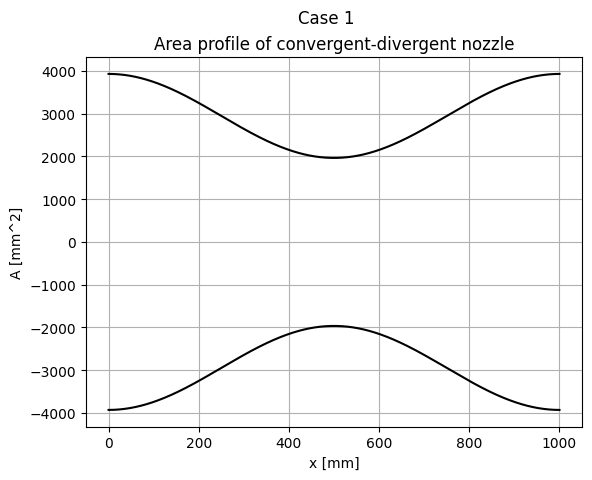

In [3]:
# Area profile
fig = plt.figure('Case 1: Area profile')
axs = fig.subplots(nrows=1, ncols=1)
axs.plot(x_mesh * 1e3, area * 1e6 / 2, color='k')
axs.plot(x_mesh * 1e3, - area * 1e6 / 2, color='k')
axs.grid(True)
axs.set_title('Area profile of convergent-divergent nozzle')
axs.set_xlabel('x [mm]'), axs.set_ylabel('A [mm^2]')
_ = fig.suptitle('Case 1')

#### Initial condition

The initial condition is specified at *Normal Temperature and Pressure* (NTP).

In [4]:
## Specify initial condition
uu_initial = np.array(
    [
        np.full_like(x_mesh, 1.0) * area,
        np.full_like(x_mesh, 0.0) * area,
        np.full_like(x_mesh, 250000) * area,
    ]
)
flux = mdl_condivnoz.flux(uu=uu_initial,
                gamma=np.full_like(x_mesh, gamma))
thermo = mdl_condivnoz.thermo(uu=uu_initial,
                    gamma=np.full_like(x_mesh, gamma))
source = mdl_condivnoz.source(uu=uu_initial,
                    gamma=np.full_like(x_mesh, gamma))

#### Boundary condition

1. *Inlet*: 
    * Mass: Neumann
    * Total Pressure: Dirichlet
    * Energy: Neumann
2. *Outlet*:
    * _Mass_: Neumann
    * _Total Pressure_: Dirichlet
    * _Energy_: Neumann

In [5]:
## Specify boundary conditions
intake = {
    Category.MF: {Type.NE: float(0)},
    Category.TP: {Type.DI: float(120000)},
    Category.TH: {Type.NE: float(0)},
}
outlet = {
    Category.MF: {Type.NE: float(0)},
    Category.TP: {Type.DI: float(100000)},
    Category.TH: {Type.NE: float(0)},
}
soln_condivnoz = Solver(model=mdl_condivnoz, initial_solution=uu_initial,
              intake_boundary=intake, outlet_boundary=outlet)
soln_condivnoz.gamma = np.full_like(x_mesh, gamma)

#### Solve

Time marching to 25 [ms] to get to steady-state solution. The time marching at equal time stepping of 1e-6 [s].

In [6]:
## Time marching
t, dt = 0, 1e-6
t_final = 25e-3

t_progress = progress(total=t_final / dt)  # Assuming equal time stepping
while t <= t_final:
    soln_condivnoz.update(dt=dt)
    t += dt
    t_progress.update()
t_progress.close()

100%|█████████▉| 25000/25000.000000000004 [00:12<00:00, 2040.19it/s]


##### Plots of thermodynamic states of steady-state solution

Plots of properties against length of pipe $x$

_Properties_:
* Velocity
* Static Pressure
* Density
* Temperature

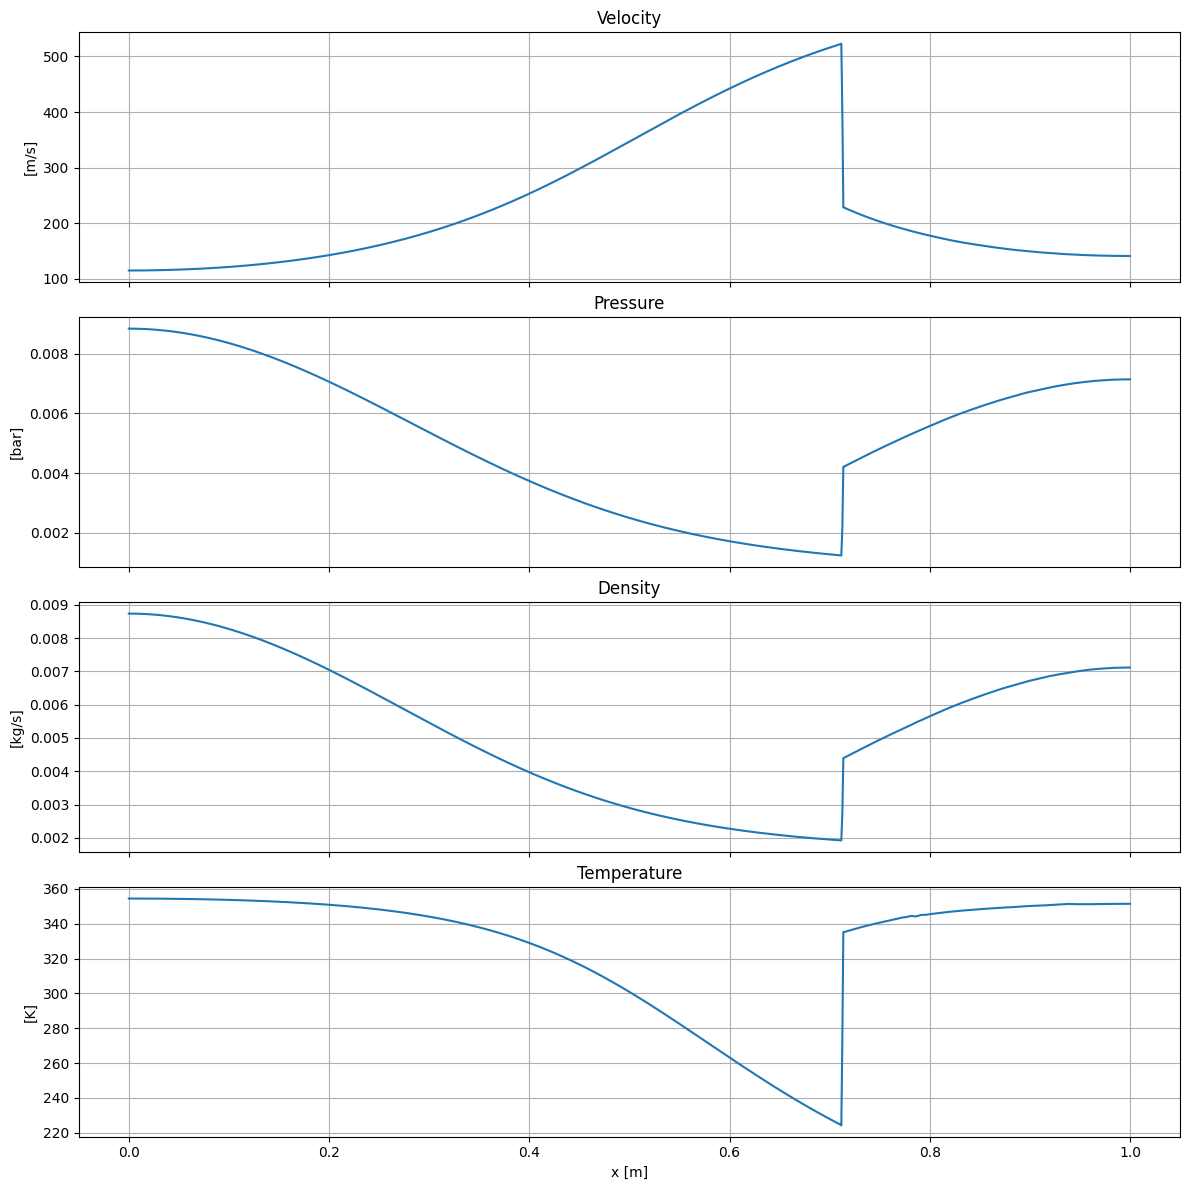

In [7]:
## Plot the final state
fig = plt.figure('Case 1: Solution at final time')
axs = fig.subplots(nrows=4, ncols=1, sharex=True)
axs[0].plot(
    x_mesh,
    mdl_condivnoz.thermo(uu=soln_condivnoz.uu, gamma=soln_condivnoz.gamma)['velocity'],
)
axs[0].set_ylabel('[m/s]')
axs[0].set_title('Velocity')
axs[1].plot(
    x_mesh,
    mdl_condivnoz.thermo(uu=soln_condivnoz.uu, gamma=soln_condivnoz.gamma)['pressure'] / 1e5,
)
axs[1].set_ylabel('[bar]')
axs[1].set_title('Pressure')
axs[2].plot(
    x_mesh,
    mdl_condivnoz.thermo(uu=soln_condivnoz.uu, gamma=soln_condivnoz.gamma)['density'],
)
axs[2].set_ylabel('[kg/s]')
axs[2].set_title('Density')
axs[3].plot(
    x_mesh,
    mdl_condivnoz.thermo(uu=soln_condivnoz.uu, gamma=soln_condivnoz.gamma)['internal_energy'] / 714.28,
)
axs[3].set_ylabel('[K]')
axs[3].set_title('Temperature')
axs[3].set_xlabel('x [m]')
_ = [ax.grid(True) for ax in axs.flat]
_ = fig.set_size_inches(w=12, h=12,)
_ = fig.tight_layout(w_pad=0.5, h_pad=0.5)

#### Discussion

The steady-state solution is well-behaved of the flow through a convergent-divergent nozzle. Needs comparison against analytical data.

### Case 2: Shock tube

In this canninical flow example we have a shock tube with diaphragm in the high pressure inlet side and closed wall on the outlet side. The diaphragm is punctured allowing compression pressure waves to form and travel along the tube and reflext off a wall on the outlet side of the tube.

[An example](https://en.wikipedia.org/wiki/Shock_tube#/media/File:Shock_tube.png) of shock tube is to let the compression and expansion wave travel at the speed of pressure waves $c \equiv \sqrt{(\frac{\partial{P}}{\partial{\rho}})_s}$, which assuming ideal gas is $c \simeq \sqrt{\gamma R T}$

#### Setup the model

1D constant area pipe with 10 [m] length. Constant $\gamma = 1.4$

In [8]:
## Setup model
x_mesh = np.linspace(-3, 7, 10000)
gamma = 1.4
area_ = 0.001
density_ = np.full_like(x_mesh, 1.0)
density_[x_mesh < 0] = 2
mdl_shock_tube = Model(
    x=x_mesh,
    area=np.full_like(x_mesh, area_),
    perimeter=np.full_like(x_mesh, 1),
    mdot_w=np.full_like(x_mesh, 0),
    tau_w=np.full_like(x_mesh, 0),
    q_w=np.full_like(x_mesh, 0),
)

#### Initial condition

The initial condition of the shock tube is such that:

1. $\rho(x<0) = 2 [kg/m^3]$
2. $\rho(x>=0) = 1 [kg/m^3]$

The shock tube is initialized with normal temperature.

In [9]:
## Specify initial condition
uu_initial = np.array(
    [
        np.full_like(x_mesh, 1.0) * area_ * density_,
        np.full_like(x_mesh, 0.0) * area_ * density_,
        np.full_like(x_mesh, 250000) * area_ * density_,
    ]
)
flux = mdl_shock_tube.flux(uu=uu_initial,
                gamma=np.full_like(x_mesh, gamma))
thermo = mdl_shock_tube.thermo(uu=uu_initial,
                    gamma=np.full_like(x_mesh, gamma))
source = mdl_shock_tube.source(uu=uu_initial,
                    gamma=np.full_like(x_mesh, gamma))


##### Plot the initial thermo state along the length of shock tube

Plots of

* Density: $\rho$ in $[kg/m^3]$
* Pressure: $p$ in $[bar]$

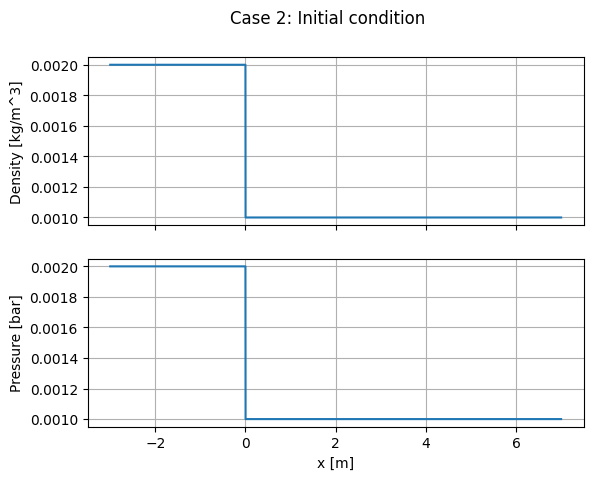

In [10]:
fig = plt.figure('Case 2: Initial density and pressure')
axs = fig.subplots(nrows=2, ncols=1, sharex=True)
axs[0].plot(
    x_mesh,
    mdl_shock_tube.thermo(
        uu=uu_initial,
        gamma=np.full_like(x_mesh, 1.4),
    )['density'],
)
axs[1].plot(
    x_mesh,
    mdl_shock_tube.thermo(
        uu=uu_initial,
        gamma=np.full_like(x_mesh, 1.4),
    )['pressure'] / 1e5,
)
_ = [ax.grid(True) for ax in axs.flat]
axs[0].set_ylabel('Density [kg/m^3]')
axs[1].set_ylabel('Pressure [bar]')
axs[-1].set_xlabel('x [m]')
_ = fig.suptitle('Case 2: Initial condition')

#### Boundary condition

The inlet and outlet boundaries are fixed walls. Pressure waves are going to reflect back into the shock tube from the walls.

1. Inlet
    * Mass: Dirichlet 0 [kg/s]
    * Total pressure: Neumann
    * Energy: Dirichlet 0 [J]
2. Outlet
    * Mass: Dirichlet 0 [kg/s]
    * Total pressure: Neumann
    * Energy: Dirichlet 0 [J]

In [11]:
## Specify the boundary conditions
intake = {
    Category.MF: {Type.DI: float(0)},
    Category.TP: {Type.NE: float(0)},
    Category.TH: {Type.DI: float(0)},
}
outlet = {
    Category.MF: {Type.DI: float(0)},
    Category.TP: {Type.NE: float(0)},
    Category.TH: {Type.DI: float(0)},
}
soln_shocktube = Solver(model=mdl_shock_tube, initial_solution=uu_initial,
              intake_boundary=intake, outlet_boundary=outlet)
soln_shocktube.gamma = np.full_like(x_mesh, gamma)

#### Solve

Time marching to 10 [m/s] from the initial condition with simulation marching forward in time in uniform time steps of 1e-6 [s].

In [12]:
## Time marching
t, dt = 0, 1e-6
t_final = 10e-3

t_progress = progress(total=t_final / dt)  # Assuming equal time stepping
while t <= t_final:
    soln_shocktube.update(dt=dt)
    t += dt
    t_progress.update()
t_progress.close()

10001it [00:24, 413.46it/s]                            


##### Plots of thermodynamic states at the end of simulation

Plots of properties against length of pipe $x$

_Properties_:
* Velocity
* Static Pressure
* Density
* Temperature

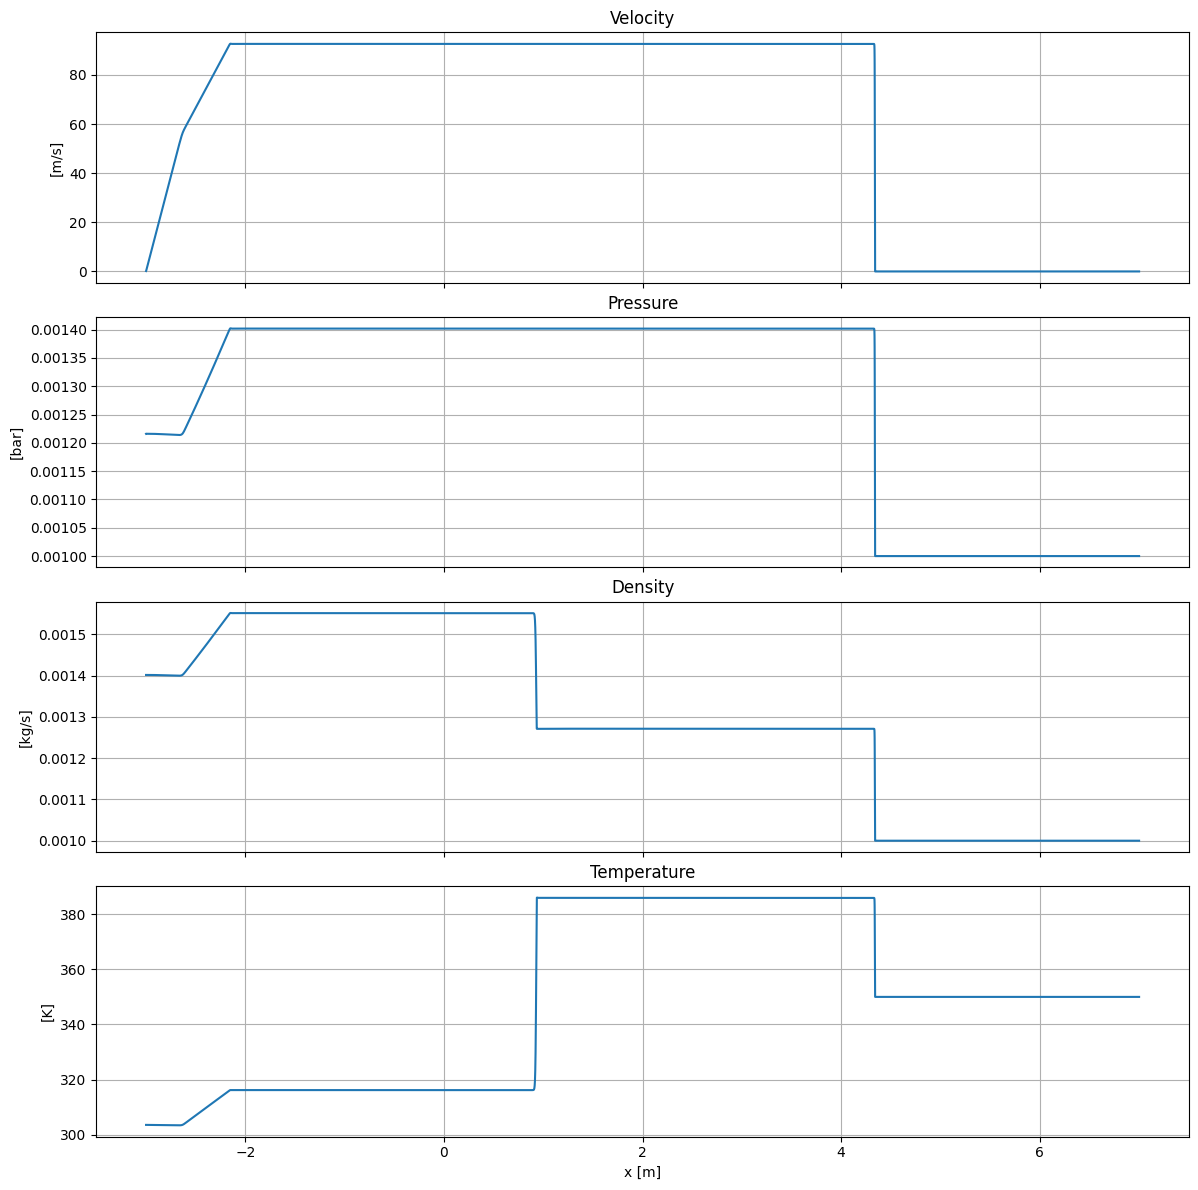

In [13]:
## Plot the final state
fig = plt.figure('Case 1: Solution at final time')
axs = fig.subplots(nrows=4, ncols=1, sharex=True)
axs[0].plot(
    x_mesh,
    mdl_shock_tube.thermo(uu=soln_shocktube.uu, gamma=soln_shocktube.gamma)['velocity'],
)
axs[0].set_ylabel('[m/s]')
axs[0].set_title('Velocity')
axs[1].plot(
    x_mesh,
    mdl_shock_tube.thermo(uu=soln_shocktube.uu, gamma=soln_shocktube.gamma)['pressure'] / 1e5,
)
axs[1].set_ylabel('[bar]')
axs[1].set_title('Pressure')
axs[2].plot(
    x_mesh,
    mdl_shock_tube.thermo(uu=soln_shocktube.uu, gamma=soln_shocktube.gamma)['density'],
)
axs[2].set_ylabel('[kg/s]')
axs[2].set_title('Density')
axs[3].plot(
    x_mesh,
    mdl_shock_tube.thermo(uu=soln_shocktube.uu, gamma=soln_shocktube.gamma)['internal_energy'] / 714.28,
)
axs[3].set_ylabel('[K]')
axs[3].set_title('Temperature')
axs[3].set_xlabel('x [m]')
_ = [ax.grid(True) for ax in axs.flat]
_ = fig.set_size_inches(w=12, h=12,)
_ = fig.tight_layout(w_pad=0.5, h_pad=0.5)

#### Discussion

The solution is well-behaved. Needs comparison against analytical solution and validation of pressure wave speed.

_Observations_
* The compression wave traversed from $x=0 [m]$ to $x \simeq 4.2 [m]$ in 10 [m/s].
* The compression shock wave is sharp and the pressure wave is resolved well.
* Needs explaination on the expansion waves at $x < 0 [m]$.
* Need discussion on characteristic waves, wave reflection, wave speeds and superpositions.

### Case 3: Pipe acoustic

Give a sine pressure wave in the inlet and let the outlet be open as well. Observe the standing wave and pipe acoustics.


### Case 4: Source in the middle of pipe

Give a steady source of mass in the center of the pipe and observe mass dissipation in 1D pipe.

#### Setup the model

1D pipe with constant area and 1 [m] length. The pipe extends from -0.005 [m] to 0.005 [m] and mass is injected at the center 0 [m] location at the rate of 10 [kg/s]. The pipe is initially at _NTP_. The walls are heated and constant heat energy rate is added uniformly across the pipe's wall at 0.1 [W/m].

In [14]:
## Setup the model
x_mesh = np.linspace(-0.5, 0.5, 1000)
gamma = 1.4
area_ = 0.001
mdot_w_ = np.full_like(x_mesh, 0.0)
mdot_w_[np.argwhere(np.abs(x_mesh) <= 0.005)] = 10
mdl_injection = Model(
    x=x_mesh,
    area=np.full_like(x_mesh, area_),
    perimeter=np.full_like(x_mesh, 1),
    mdot_w=mdot_w_,
    tau_w=np.full_like(x_mesh, 0),
    q_w=np.full_like(x_mesh, 0.1),
    H_inj=np.full_like(x_mesh, 350000),
)

#### Initial condition

The pipe is at _NTP_.

In [15]:
## Setup initial condition
uu_initial = np.array(
    [
        np.full_like(x_mesh, 1.0) * area_,
        np.full_like(x_mesh, 0.0) * area_,
        np.full_like(x_mesh, 250000) * area_,
    ]
)
flux = mdl_injection.flux(uu=uu_initial,
                gamma=np.full_like(x_mesh, gamma))
thermo = mdl_injection.thermo(uu=uu_initial,
                    gamma=np.full_like(x_mesh, gamma))
source = mdl_injection.source(uu=uu_initial,
                    gamma=np.full_like(x_mesh, gamma))

##### Plot the initial thermal state

Plot density and temperature against length of the tube at $t = 0 [s]$

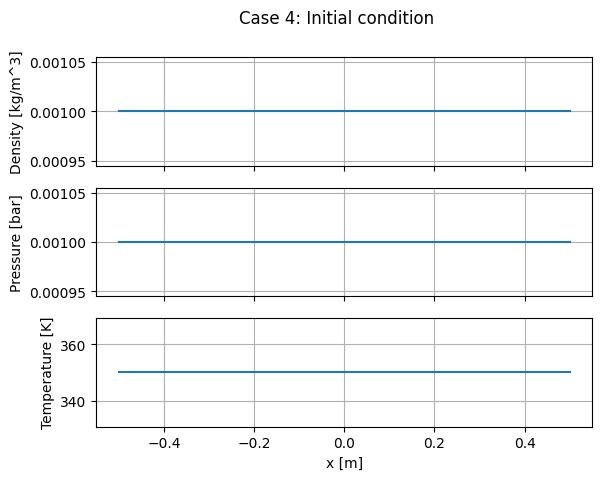

In [16]:
fig = plt.figure('Case 4: Initial density, pressure and temperature')
axs = fig.subplots(nrows=3, ncols=1, sharex=True)
axs[0].plot(
    x_mesh,
    mdl_injection.thermo(
        uu=uu_initial,
        gamma=np.full_like(x_mesh, 1.4),
    )['density'],
)
axs[1].plot(
    x_mesh,
    mdl_injection.thermo(
        uu=uu_initial,
        gamma=np.full_like(x_mesh, 1.4),
    )['pressure'] / 1e5,
)
axs[2].plot(
    x_mesh,
    mdl_injection.thermo(
        uu=uu_initial,
        gamma=np.full_like(x_mesh, 1.4),
    )['internal_energy'] / 714.28,
)
_ = [ax.grid(True) for ax in axs.flat]
axs[0].set_ylabel('Density [kg/m^3]')
axs[1].set_ylabel('Pressure [bar]')
axs[2].set_ylabel('Temperature [K]')
axs[-1].set_xlabel('x [m]')
_ = fig.suptitle('Case 4: Initial condition')

#### Boundary condition

In this case the inlet and outlet walls are closed, allowing no heat or mass exchanges. The walls are heated, allowing heat exchange into the system. In the middle of the tube is a mass injection site, allowing a mass source.

In [17]:
## Setup the boundary conditions
intake = {
    Category.MF: {Type.DI: float(0)},
    Category.TP: {Type.NE: float(0)},
    Category.TH: {Type.DI: float(0)},
}
outlet = {
    Category.MF: {Type.DI: float(0)},
    Category.TP: {Type.NE: float(0)},
    Category.TH: {Type.DI: float(0)},
}
soln_injection = Solver(model=mdl_injection, initial_solution=uu_initial,
              intake_boundary=intake, outlet_boundary=outlet)
soln_injection.gamma = np.full_like(x_mesh, gamma)

#### Solve

Time marching to 10 [m/s] from the initial condition with simulation marching forward in time in uniform time steps of 1e-6 [s].

In [18]:
## Time marching
t, dt = 0, 1e-6
t_final = 10e-3

t_progress = progress(total=t_final / dt)  # Assuming equal time stepping
while t <= t_final:
    soln_injection.update(dt=dt)
    t += dt
    t_progress.update()
t_progress.close()

10001it [00:05, 1958.03it/s]                            


##### Plots of thermodynamic states

Plots of thermodynamics states against $x$

1. Pressure
2. Density
3. Temperature

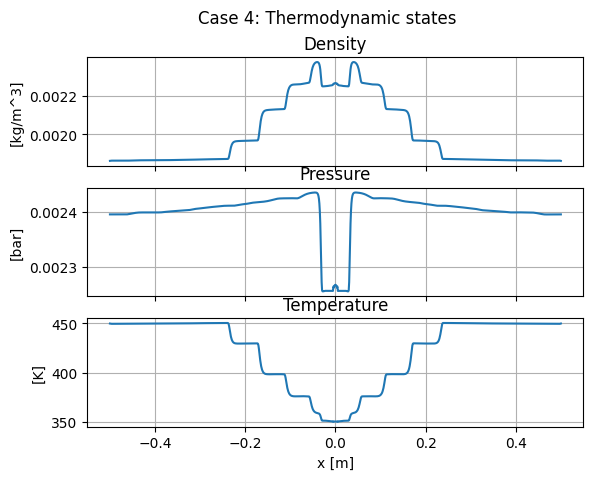

In [19]:
## Plot the final state
fig = plt.figure('Case 4: Solution at final time')
axs = fig.subplots(nrows=3, ncols=1, sharex=True)
axs[0].plot(
    x_mesh,
    mdl_injection.thermo(uu=soln_injection.uu, gamma=soln_injection.gamma)['density'],
)
axs[0].set_ylabel('[kg/m^3]')
axs[0].set_title('Density')
axs[1].plot(
    x_mesh,
    mdl_injection.thermo(uu=soln_injection.uu, gamma=soln_injection.gamma)['pressure'] / 1e5,
)
axs[1].set_ylabel('[bar]')
axs[1].set_title('Pressure')
axs[2].plot(
    x_mesh,
    mdl_injection.thermo(uu=soln_injection.uu, gamma=soln_injection.gamma)['internal_energy'] / 714.28,
)
axs[2].set_ylabel('[K]')
axs[2].set_title('Temperature')
axs[2].set_xlabel('x [m]')
_ = [ax.grid(True) for ax in axs.flat]
_ = fig.suptitle('Case 4: Thermodynamic states')